# Bilayer Graphene band structure

**Reminder for the monolayer case**

chosing the bravias lattive vectors:

$$\vec{a}_1 = a\left(\frac{\sqrt{3}}{2}, \frac{3}{2}\right), \quad
 \vec{a}_2 = a\left(-\frac{\sqrt{3}}{2}, \frac{3}{2}\right)$$


The nearest neigbhor vectors from the A atom are:

$$\vec{\delta_1} = a\left(0,1\right), \quad
\vec{\delta_2} = a\left(\frac{\sqrt{3}}{2}, -\frac{1}{2}\right), \quad
\vec{\delta_3} = a\left(\frac{-\sqrt{3}}{2}, -\frac{1}{2}\right)$$


**Basis**

AB bilayer has 4 atoms per unit cell: $ A_1 $ and $ B_1$ on layer 1 and $A_1$ and $B_2$ on layer 2.

So our new Bloch basis is:

$$

\ket{A_1,\mathbf{k}} \quad
\ket{B_1,\mathbf{k}} \quad
\ket{A_2,\mathbf{k}} \quad
\ket{B_2,\mathbf{k}}
$$





**Hopping within layers**

Similarly to the for the single layer hopping term from $A_{1,2} \to B_{1,2} $ is $-\gamma{}_0f(\mathbf{k}) $, and from $B_{1,2}  \to A_{1,2} $ is $-\gamma{}_0f^*(\mathbf{k}) $.

$$
H_{2\times{}2}(\mathbf{k}) = \begin{pmatrix} 0 & -\gamma{}_0f(\mathbf{k}) \\ -\gamma{}_0f^*(\mathbf{k}) & 0 \end{pmatrix}
$$

**Hopping between layers**

Adding dimer coupling between $B_1$ and $A_1$

$$
\bra{B_1}H\ket{A_2} = \gamma{}_1
\quad
\bra{A_2}H\ket{B_1} = \gamma{}_1
$$

Together we get:

$$

H_{4\times{}4}(\mathbf{k}) = 

\begin{pmatrix}

0 & -\gamma{}_0f & 0 & 0 \\
-\gamma{}_0f^* & 0 & \gamma{}_1 & 0 \\
0 & \gamma{}_1 & 0 & -\gamma{}_0f \\ 
0 & 0 & -\gamma{}_0f^* & 0 

\end{pmatrix}


$$


**Diagonalizing the 4x4 Hamiltonian**

$$
\det\!\begin{pmatrix}

-E & -\gamma{}_0f(\mathbf{k}) & 0 & 0 \\
-\gamma{}_0f^*(\mathbf{k}) & -E & \gamma{}_1 & 0 \\
0 & \gamma{}_1 & -E & -\gamma{}_0f(\mathbf{k}) \\ 
0 & 0 & -\gamma{}_0f^*(\mathbf{k}) & -E

\end{pmatrix} = 0

$$

After some algebra:

$$
\Big( E^2 + E\gamma{}_1 -(\gamma{}_0|f(\mathbf{k})|)^2  \Big)\Big( E^2 - E\gamma{}_1 -(\gamma{}_0|f(\mathbf{k})|)^2 \Big)  = 0
$$

And solving the quadratic equations, will get you the 4 bands:

$$

E_{A \pm} = \frac{-\gamma{}_1 \pm \sqrt{\gamma{}_1^2+4\gamma{}_0^2(|f(\mathbf{k})|)^2}}{2} \quad \quad

E_{B \pm}  = \frac{\gamma{}_1 \pm \sqrt{\gamma{}_1^2+4\gamma{}_0^2(|f(\mathbf{k})|)^2}}{2}

$$



## Plotting the band stractures near the dirac point

As we saw in the monolayer case:

- $|f(\mathbf{k})|^2 = 1 + 4\cos{ \left(\frac{\sqrt{3}}{2} k_xa\right)}\cos\left(\frac{3k_ya}{2}\right) + 4\cos^2{ \left(\frac{\sqrt{3}}{2} k_xa\right)}$
- The dirac point: $\mathbf{k} = \left(\frac{4\pi{}}{3\sqrt{3}a}, 0\right)$
- near the dirac point $f(\mathbf{k}) = 0$ 



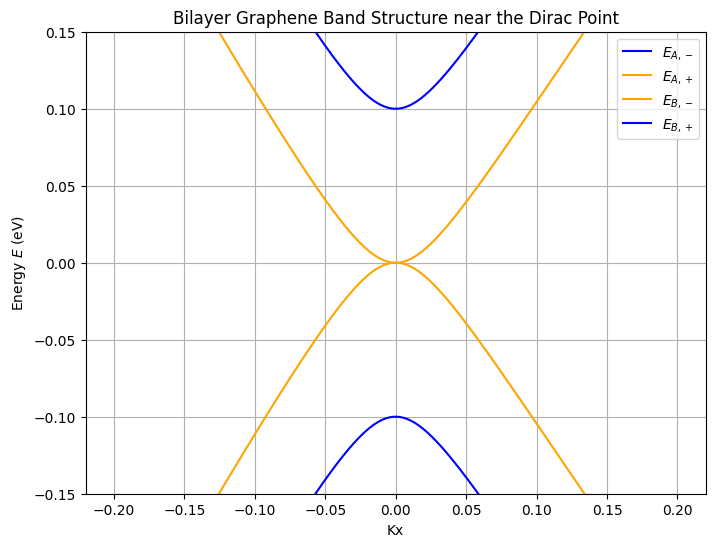

In [20]:
import numpy as np
import matplotlib.pyplot as plt

gamma0 = 1.0  
gamma1 = 0.1  
a = 1.0     

# Dirac point x value
K_x = (4 * np.pi) / (3 * np.sqrt(3) * a) 




def f_k(kx_a, ky_a):

    return 1 + 4 * np.cos(np.sqrt(3)/2 * kx_a) * np.cos(3 * ky_a / 2) + 4 * (np.cos(np.sqrt(3)/2 * kx_a))**2

def eigen_energies(kx, ky, gamma0, gamma1, a):

    f = f_k(kx * a, ky * a)
    sqrt_term = np.sqrt(gamma1**2 + 4 * gamma0**2 * f)

    E_A_minus = (-gamma1 - sqrt_term) / 2
    E_A_plus  = (-gamma1 + sqrt_term) / 2
    E_B_minus = (gamma1 - sqrt_term) / 2
    E_B_plus  = (gamma1 + sqrt_term) / 2
    
    return E_A_minus, E_A_plus, E_B_minus, E_B_plus




ky_path = 0.0
k_range = np.linspace(K_x - 0.2, K_x + 0.2, 500) 
E1, E2, E3, E4 = eigen_energies(k_range, ky_path, gamma0, gamma1, a)

plt.figure(figsize=(8, 6))
plt.plot(k_range - K_x, E1, color= "blue", label='$E_{A,-}$')
plt.plot(k_range - K_x, E2, color="orange", label='$E_{A,+}$')
plt.plot(k_range - K_x, E3,color="orange", label='$E_{B,-}$')
plt.plot(k_range - K_x, E4, color= "blue", label='$E_{B,+}$')



# Formatting
plt.title('Bilayer Graphene Band Structure near the Dirac Point')
plt.xlabel('Kx')
plt.ylabel('Energy $E$ (eV)')
plt.ylim(-1.5 * gamma1, 1.5 * gamma1) 
plt.legend()
plt.grid()


